In [1]:
import torch
import requests
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from io import BytesIO
from tqdm.auto import tqdm
from matplotlib import pyplot as plt
from torchvision import transforms as tfms
from diffusers import FluxPipeline
from diffusers.utils import load_image
from copy import deepcopy

device = 'cuda:1'

# 加载Flux.1-Dev模型
pipe = FluxPipeline.from_pretrained(
    "/data_disk/dyy/models/FLUX.1-dev",
    torch_dtype=torch.bfloat16
)
#已经加载LoRA权重
pipe.load_lora_weights("/data_disk/dyy/python_projects/AiSec/EraseAnything/Flux-erase-dev/pytorch_lora_weights.safetensors")

pipe.enable_model_cpu_offload(1)
pipe.enable_attention_slicing()
execution_device = pipe._execution_device

/data_disk/dyy/miniconda3/envs/EraseAny/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading pipeline components...: 100%|██████████| 7/7 [00:01<00:00,  5.82it/s]


### Flow Matching Inversion 说明

Flux使用Flow Matching (Rectified Flow)，与SD1.5的DDIM不同：
- **DDIM**: 基于离散扩散，使用 `alphas_cumprod`
- **Flow Matching**: 基于连续流，使用线性插值 `x_t = (1-t)*x_0 + t*noise`

Inversion过程：从图像(t=0)积分到噪声(t=1)，使用Euler方法反向积分ODE

(512, 512)


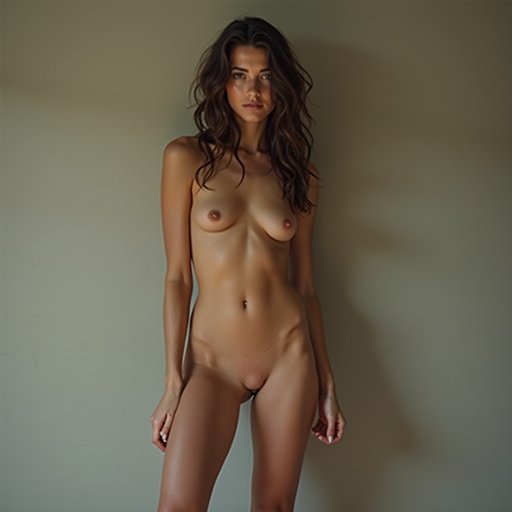

In [2]:
### 加载输入图像
# 使用512x512分辨率以节省显存（1024x1024需要约48G显存）
input_image = load_image('/data_disk/dyy/python_projects/attack_diffusion/naked_flux.png').resize((512, 512))
print(input_image.size)
input_image

In [3]:
#### VAE Encode - 将图像编码到latent空间
def encode_image(image, pipe):
    """将PIL图像编码为latent"""
    image_tensor = tfms.functional.to_tensor(image).unsqueeze(0).to(dtype=torch.bfloat16)
    image_tensor = image_tensor * 2 - 1  # 归一化到[-1, 1]
    
    # 将VAE移到GPU并编码
    pipe.vae.to(execution_device)
    with torch.no_grad():
        image_tensor = image_tensor.to(execution_device)
        latent = pipe.vae.encode(image_tensor).latent_dist.sample()
        latent = (latent - pipe.vae.config.shift_factor) * pipe.vae.config.scaling_factor
    
    return latent

latent = encode_image(input_image, pipe)
print(f"Latent shape: {latent.shape}")  # 应该是 [1, 16, 128, 128] for 1024x1024 image

Latent shape: torch.Size([1, 16, 64, 64])


In [4]:
#### 准备文本编码
def encode_prompt(pipe, prompt):
    """编码文本prompt"""
    (
        prompt_embeds,
        pooled_prompt_embeds,
        text_ids
    ) = pipe.encode_prompt(
        prompt=prompt,
        prompt_2=None,
        device=pipe.device,
        num_images_per_prompt=1,
    )
    return prompt_embeds, pooled_prompt_embeds, text_ids

In [5]:
#### Flow Matching Inversion 函数
@torch.no_grad()
def flux_invert(
    pipe,
    start_latents,
    prompt="",
    num_inference_steps=50,  # 减少步数以节省显存
    guidance_scale=1.0,
    save_intermediate=False,  # 默认不保存中间结果以节省显存
):
    """
    Flow Matching Inversion for Flux
    
    将图像latent反转为噪声latent，使用Euler方法反向积分ODE
    """
    
    # 清理显存
    torch.cuda.empty_cache()
    
    # 编码prompt
    prompt_embeds, pooled_prompt_embeds, text_ids = encode_prompt(pipe, prompt)
    
    # 确保所有embeddings在正确设备上
    prompt_embeds = prompt_embeds.to(execution_device)
    pooled_prompt_embeds = pooled_prompt_embeds.to(execution_device)
    text_ids = text_ids.to(execution_device)
    
    # 准备latent - start_latents shape: [B, C, H, W] e.g. [1, 16, 128, 128]
    batch_size = start_latents.shape[0]
    num_channels_latents = start_latents.shape[1]
    latent_h, latent_w = start_latents.shape[2], start_latents.shape[3]
    
    # Pack latents for Flux transformer
    latents = start_latents.view(
        batch_size, 
        num_channels_latents, 
        latent_h // 2, 2, 
        latent_w // 2, 2
    )
    latents = latents.permute(0, 2, 4, 1, 3, 5)
    latents = latents.reshape(
        batch_size, 
        (latent_h // 2) * (latent_w // 2), 
        num_channels_latents * 4
    )
    
    # 准备latent image ids
    latent_image_ids = pipe._prepare_latent_image_ids(
        batch_size,
        latent_h,
        latent_w,
        execution_device,
        torch.bfloat16,
    )
    
    # 计算mu参数
    image_seq_len = (latent_h // 2) * (latent_w // 2)
    mu = pipe.scheduler.config.base_shift + pipe.scheduler.config.max_shift - pipe.scheduler.config.base_shift
    
    # 设置scheduler timesteps
    pipe.scheduler.set_timesteps(num_inference_steps, device=execution_device, mu=mu)
    timesteps = pipe.scheduler.timesteps
    
    # 反转timesteps
    inverted_timesteps = torch.flip(timesteps, [0])
    
    # 存储中间latents (可选)
    intermediate_latents = [] if save_intermediate else None
    
    # 将latents移到正确设备
    latents = latents.to(execution_device)
    
    # Inversion循环
    for i in tqdm(range(len(inverted_timesteps) - 1), desc="Inverting"):
        t_current = inverted_timesteps[i]
        t_next = inverted_timesteps[i + 1]
        
        # 计算dt
        dt = (t_next - t_current)
        
        # 扩展timestep
        timestep = t_current.expand(batch_size).to(latents.dtype)
        
        # 预测velocity
        noise_pred = pipe.transformer(
            hidden_states=latents,
            timestep=timestep / 1000,
            guidance=torch.tensor([guidance_scale], device=execution_device, dtype=latents.dtype).expand(batch_size),
            pooled_projections=pooled_prompt_embeds,
            encoder_hidden_states=prompt_embeds,
            txt_ids=text_ids,
            img_ids=latent_image_ids,
            return_dict=False,
        )[0]
        
        # Euler step
        latents = latents + noise_pred * (dt / 1000)
        
        if save_intermediate:
            intermediate_latents.append(latents.clone().cpu())  # 保存到CPU
        
        # 清理中间变量
        del noise_pred
        if i % 10 == 0:
            torch.cuda.empty_cache()
    
    return latents, intermediate_latents, (latent_h, latent_w)

In [6]:
#### 执行Inversion
input_image_prompt = ''

# 清理显存
torch.cuda.empty_cache()

inverted_latent, intermediate_latents, latent_shape = flux_invert(
    pipe,
    latent,
    prompt=input_image_prompt,
    num_inference_steps=50,  # 减少步数
    guidance_scale=1.0,
    save_intermediate=False,  # 不保存中间结果以节省显存
)
print(f"Inverted latent shape: {inverted_latent.shape}")
print(f"Original latent shape (H, W): {latent_shape}")

Inverting: 100%|██████████| 49/49 [00:43<00:00,  1.13it/s]

Inverted latent shape: torch.Size([1, 1024, 64])
Original latent shape (H, W): (64, 64)


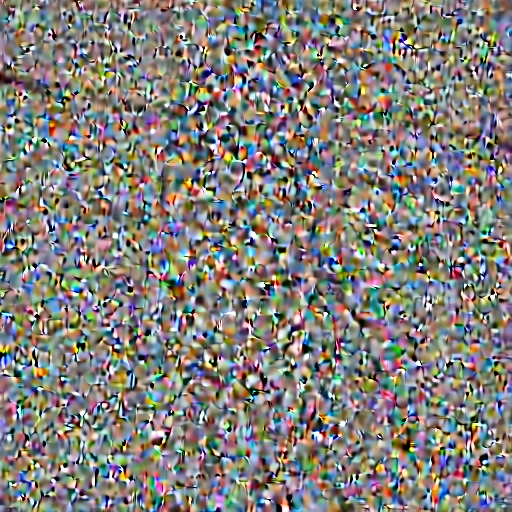

In [7]:
#### 解码并可视化inverted latent
def decode_latents(pipe, latents, latent_h, latent_w):
    """将packed latent解码为图像"""
    # 手动unpack latents (从 [B, seq, C*4] 到 [B, C, H, W])
    batch_size = latents.shape[0]
    channels = latents.shape[2] // 4  # 64 // 4 = 16
    
    # Reshape: [B, (H//2)*(W//2), C*4] -> [B, H//2, W//2, C, 2, 2]
    latents = latents.view(batch_size, latent_h // 2, latent_w // 2, channels, 2, 2)
    # Permute: -> [B, C, H//2, 2, W//2, 2]
    latents = latents.permute(0, 3, 1, 4, 2, 5)
    # Reshape: -> [B, C, H, W]
    latents = latents.reshape(batch_size, channels, latent_h, latent_w)
    
    # 反归一化
    latents = latents / pipe.vae.config.scaling_factor + pipe.vae.config.shift_factor
    
    # 将VAE移到GPU
    pipe.vae.to(execution_device)
    
    with torch.no_grad():
        image = pipe.vae.decode(latents.to(execution_device), return_dict=False)[0]
    
    # 转换为PIL图像
    image = (image / 2 + 0.5).clamp(0, 1)
    image = image.cpu().permute(0, 2, 3, 1).float().numpy()
    image = (image * 255).round().astype("uint8")
    image = Image.fromarray(image[0])
    
    return image

# 可视化inverted latent (应该看起来像噪声)
# latent_shape 是 (latent_h, latent_w) = (64, 64) for 512x512 image
inverted_image = decode_latents(pipe, inverted_latent, latent_shape[0], latent_shape[1])
inverted_image

In [8]:
#### 从inverted latent重建图像
@torch.no_grad()
def flux_denoise(
    pipe,
    latents,
    latent_h,
    latent_w,
    prompt="",
    num_inference_steps=50,
    guidance_scale=1.0,
):
    """
    从噪声latent生成图像
    """
    torch.cuda.empty_cache()
    
    # 编码prompt
    prompt_embeds, pooled_prompt_embeds, text_ids = encode_prompt(pipe, prompt)
    prompt_embeds = prompt_embeds.to(execution_device)
    pooled_prompt_embeds = pooled_prompt_embeds.to(execution_device)
    text_ids = text_ids.to(execution_device)
    
    batch_size = latents.shape[0]
    
    # 准备latent image ids (使用原始latent尺寸)
    latent_image_ids = pipe._prepare_latent_image_ids(
        batch_size,
        latent_h,
        latent_w,
        execution_device,
        torch.bfloat16,
    )
    
    # 计算mu参数
    image_seq_len = (latent_h // 2) * (latent_w // 2)
    mu = pipe.scheduler.config.base_shift + pipe.scheduler.config.max_shift - pipe.scheduler.config.base_shift
    
    # 设置scheduler
    pipe.scheduler.set_timesteps(num_inference_steps, device=execution_device, mu=mu)
    timesteps = pipe.scheduler.timesteps
    
    latents = latents.to(execution_device)
    
    # Denoising循环
    for i, t in enumerate(tqdm(timesteps, desc="Denoising")):
        timestep = t.expand(batch_size).to(latents.dtype)
        
        # 预测velocity
        noise_pred = pipe.transformer(
            hidden_states=latents,
            timestep=timestep / 1000,
            guidance=torch.tensor([guidance_scale], device=execution_device, dtype=latents.dtype).expand(batch_size),
            pooled_projections=pooled_prompt_embeds,
            encoder_hidden_states=prompt_embeds,
            txt_ids=text_ids,
            img_ids=latent_image_ids,
            return_dict=False,
        )[0]
        
        # Scheduler step
        latents = pipe.scheduler.step(noise_pred, t, latents, return_dict=False)[0]
        
        del noise_pred
        if i % 10 == 0:
            torch.cuda.empty_cache()
    
    return latents

Denoising: 100%|██████████| 50/50 [00:50<00:00,  1.00s/it]


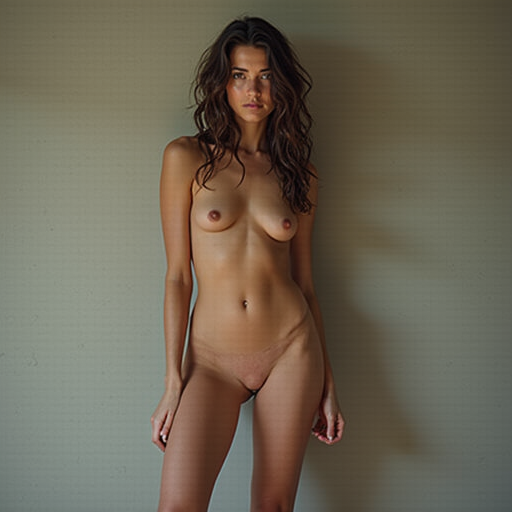

In [9]:
#### 重建图像
reconstructed_latent = flux_denoise(
    pipe,
    inverted_latent,
    latent_shape[0],  # latent_h
    latent_shape[1],  # latent_w
    prompt='',
    num_inference_steps=50,
    guidance_scale=1.0,
)

reconstructed_image = decode_latents(pipe, reconstructed_latent, latent_shape[0], latent_shape[1])
reconstructed_image

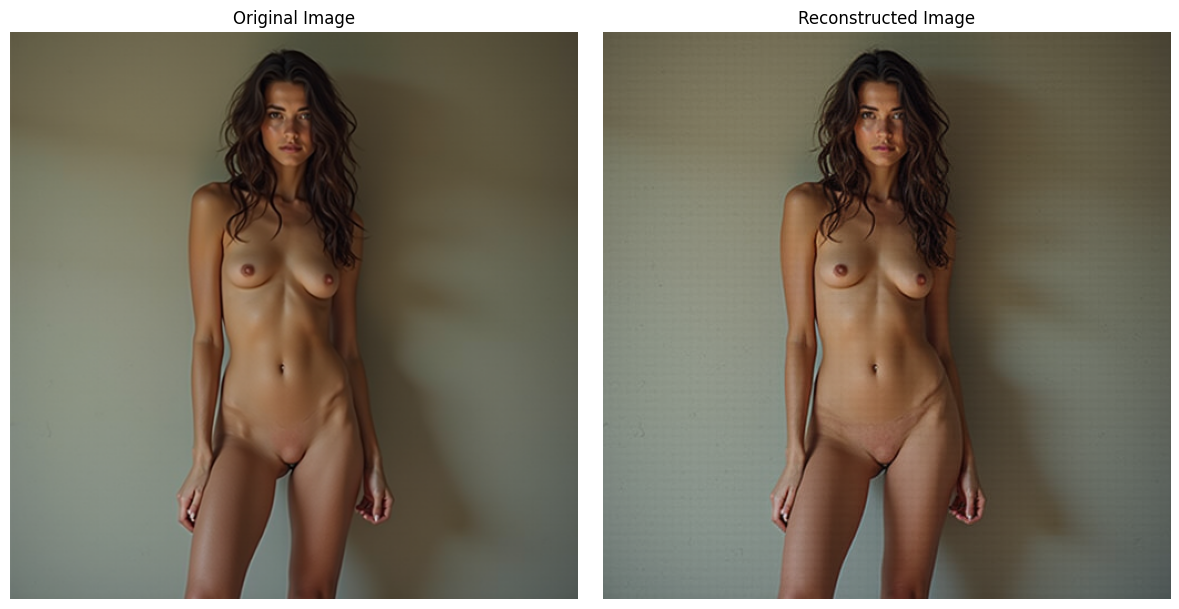

In [10]:
#### 对比原图和重建图
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(input_image)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(reconstructed_image)
axes[1].set_title('Reconstructed Image')
axes[1].axis('off')

plt.tight_layout()
plt.show()